In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

In [2]:
# importing dataset
# ---1 connect to the db 
conn = sqlite3.connect("customer_churn.db")

# running sql query 
sql_query = """
    SELECT name FROM sqlite_master
    WHERE type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

# create dabaframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Create dataframe: df_{table_name}")

conn.close()

Create dataframe: df_db_customer
Create dataframe: df_db_subscription
Create dataframe: df_db_support


In [3]:
conn = sqlite3.connect("customer_churn.db")

for table_name in tables['name']:
    print(f'\nTable Name : {table_name}')

    # to get col info
    col_query = f"PRAGMA table_info({table_name}) "
    columns  = pd.read_sql(col_query,conn)
    print('Column: ')
    print(columns['name'].tolist())

# close connection
conn.close()


Table Name : db_customer
Column: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name : db_subscription
Column: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name : db_support
Column: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
# Data cleaning

In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


### drop col - interest and pincode
### changing the column name  - name to customer_name
### filling the countries
### changing datatye of DOB
### fixing /data standardization of gender


In [8]:
# changing the column name  - name to customer_name
df_db_customer.rename(columns={'name' : "customer_name"}, inplace= True)

In [9]:
# drop col - interest and pincode
df_db_customer.drop(df_db_customer.columns[-2:], axis =1, inplace=True)
# simple way 
# df_db_customer.drop(columns= ['interests', 'pincode'])


In [10]:
# changing datatye of DOB
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [11]:
# fixing /data standardization of gender
df_db_customer['gender'].unique()


array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [12]:
df_db_customer['gender'] =  df_db_customer['gender'].replace({'Men' : "Male" , "Women": "Female"})

In [13]:
 # filling the countries
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [14]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [15]:
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [16]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [17]:
df_db_customer.tail()

,customerid,customer_name,country,state,gender,dob
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Male,1991-05-14
20,0023-UYUPN,sudevi,India,Maharashtra,Female,1977-10-06


In [18]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [19]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


* changing datatype for subscription_start_date, renewal date,cancellation_date
* filling the cancellation_date null values
* deleting the unwanted column - cancellation_reason
  

In [20]:
date_col = ['subscription_start_date', 'renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)


In [21]:
df_db_subscription.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [22]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
df_db_support = df_db_support.drop(columns=['col_1','comment'])

In [25]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

### Feature Engineering amd Data Analysis

In [26]:
# the customer is chrned or not(churn - the customer left or is having the subscription) 
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)


In [27]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaT,None,20.99,550,62,0
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaT,None,13.99,840,27,0
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99,1
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,None,22.99,1955,7,0
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,None,13.99,790,47,0


In [28]:
# there are some duplicate customerid so to remove these we are performing these
# operations firstly

df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [29]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [30]:
df_db_support['customerid'].size

7

In [31]:
df =  (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [32]:
df.shape

(21, 21)

In [33]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [34]:
df.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaT,None,20.99,550,...,0,rikim,India,Meghalaya,Female,1994-08-19,NaT,NaN,NaN,NaN
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaT,None,13.99,840,...,0,vishakha,India,Rajasthan,Female,2000-09-02,NaT,NaN,NaN,NaN
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,1,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,90.0,2.0
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,None,22.99,1955,...,0,rishabh,India,Uttar Pradesh,Male,1991-05-14,NaT,NaN,NaN,NaN
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,None,13.99,790,...,0,sudevi,India,Maharashtra,Female,1977-10-06,NaT,NaN,NaN,NaN


In [35]:
# to convert this in csv file
df.to_csv("exported_churn_data.csv", index = False)

### Data Analysis


In [36]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [37]:
# Churn rate -  the percentage of people leaving the organization
churn_rate = df['churn_flag'].mean()*100
print(f"Churn Rate = {round(churn_rate,2) }%")


Churn Rate = 28.57%


In [38]:
# Retention rate - the percentage of people that stays with the organization
retention_rate = 100-churn_rate
print(f"Retention Rate = {round(retention_rate,2) }%")

Retention Rate = 71.43%


In [39]:
# The people that are leaving what kind of plan they were using 
# because if they are using the Premium plan_type this will affect the organization

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name ="churn_rate%")
print(f"{churn_by_plan}")

  plan_type  churn_rate%
0     Basic        60.00
1   Premium        14.29
2  Standard        22.22


In [40]:
# Churn rate by state
# churn_by_state = df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate')
# churn_by_state

churn_by_state = df.groupby('state').agg(total_revenue = ('monthly_charges','sum'),total_users = ('customerid','count')).reset_index()
churn_by_state

,state,total_revenue,total_users
0,Delhi,52.96,4
1,Karnataka,20.98,2
2,Kathmandu,20.98,2
3,Maharashtra,50.97,3
4,Meghalaya,42.97,3
5,Nagaland,22.99,1
6,Rajasthan,36.98,2
7,Telangana,30.98,2
8,Uttar Pradesh,115.98,2


In [41]:
# churn by subscription type

churn_by_subscription_type = df.groupby('subscription_type').agg(total_revenue = ("monthly_charges",'sum'), total_users = ('customerid','count')).reset_index()
churn_by_subscription_type

,subscription_type,total_revenue,total_users
0,Organic,145.91,9
1,Paid,174.94,6
2,Refferal,74.94,6


In [42]:
# ARPU - Avg Revenue per Users
arpu = df['monthly_charges'].mean().round(2)
print('ARPU: ' , arpu )

ARPU:  18.85


In [43]:
# Tenure - for how much time customer stayed (day, week, months, years)
# Average customer tenure
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean().round(0)
print("Avg Tenure: ", avg_tenure)

Avg Tenure:  1520.0


In [44]:
# Revenue at risk  -- revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag'] ==1 ,'monthly_charges'].sum()
print(f'Revenue at risk: {revenue_at_risk}')

Revenue at risk: 73.94


In [45]:
# Escalation - The problem is sent to next step when it is not solving
# Escalation Rate
escalation = (df['escalations'] == 'Y').mean()*(100)
print("Escalation Rate : ", round(escalation, 2))

Escalation Rate :  19.05


In [46]:
# Average complaint per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print('Average complaint per user: ', round(avg_complaints,2))

Average complaint per user:  0.43


In [47]:
# first converting the escalation(string part) into numeric where there is Y will
# convert into 1 otherwise 0
df['escalations'] = np.where(df['escalations'] == 'Y', 1,0)
# This line of code we need to run one time only otherwise the data can be overwritten in the table


# Correlation Escalation vs churn
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation  = (corr_df['escalations'].corr(df['churn_flag']))*100
print('Correlation between churn_flag and escalation is : ', round(correlation,2))

Correlation between churn_flag and escalation is :  76.7


In [48]:
# churn risk 
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] > 70)   
]

choices = ['low','med','high']
df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [49]:
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [50]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

### Data visualization using matplotlib


In [51]:
# Making a copy of the df
df_copy = df.copy()

In [52]:
df_copy.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [53]:
# Monthly churn trends

df_copy['cancellation_month'] = df_copy['cancellation_date'].dt.to_period('M')
# This line of code we need to run one time only otherwise the data can be overwritten in the table

In [54]:
churn_trend = df_copy[df_copy['churn_flag'] ==1 ].groupby('cancellation_month').size()

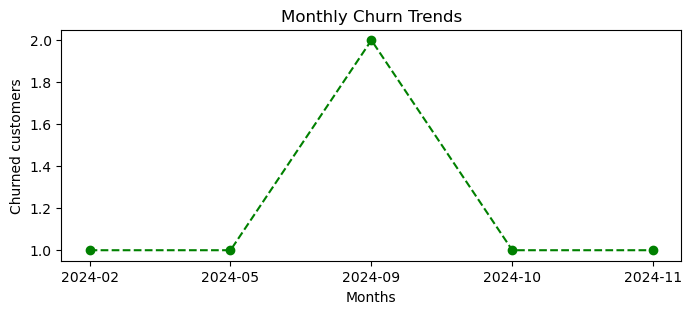

In [55]:
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed')
plt.title("Monthly Churn Trends")
plt.xlabel('Months')
plt.ylabel("Churned customers")
plt.show()

<BarContainer object of 3 artists>

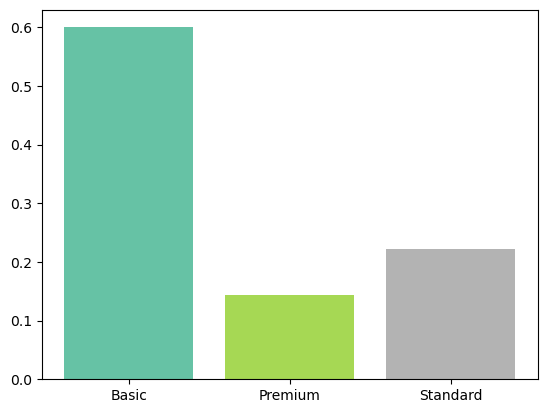

In [62]:
# CHURN by plan type
churn_type = df_copy.groupby('plan_type')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_type)))
plt.bar(churn_type.index , churn_type.values, color = colors  )

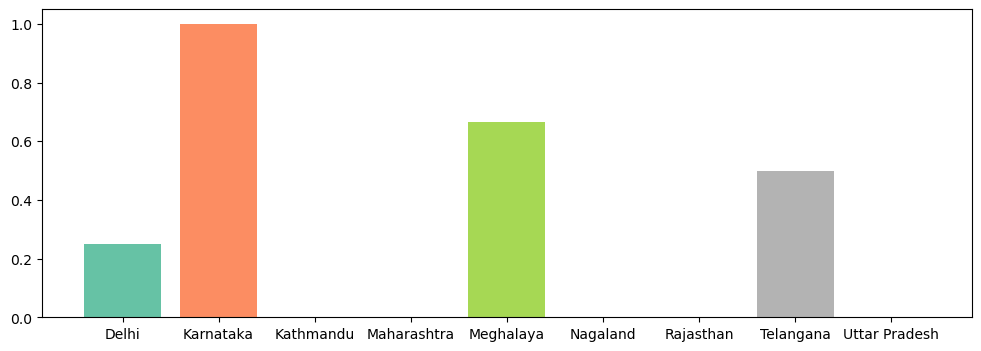

In [67]:
#  Churn by states 
churn_statewise = df_copy.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1,len(churn_statewise)))
plt.figure(figsize= (12,4))
plt.bar(churn_statewise.index, churn_statewise.values, color = colors)
plt.show()

In [68]:
df_copy.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

### Visualization Using Seaborn

In [99]:
df_copy[['plan_type','contract_type', 'churn_score',
       'churn_flag', 'churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [98]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


In [80]:
# encoding = convert str to numeric values so that we can find out correlation between them
# -----This is not hte correct method to do this because this is providing us the value 
# of the churn risk according to the alphabetical order not on the priority basis.

df_encoded = df_copy[['plan_type','contract_type', 'churn_score',
       'churn_flag', 'churn_risk','escalations']]
categorical_cols = ['plan_type','contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

C:\Users\avnig\AppData\Local\Temp\ipykernel_13016\1476003587.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = df_encoded[col].astype('category').cat.codes
C:\Users\avnig\AppData\Local\Temp\ipykernel_13016\1476003587.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = df_encoded[col].astype('category').cat.codes
C:\Users\avnig\AppData\Local\Temp\ipykernel_13016\1476003587.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

<Axes: >

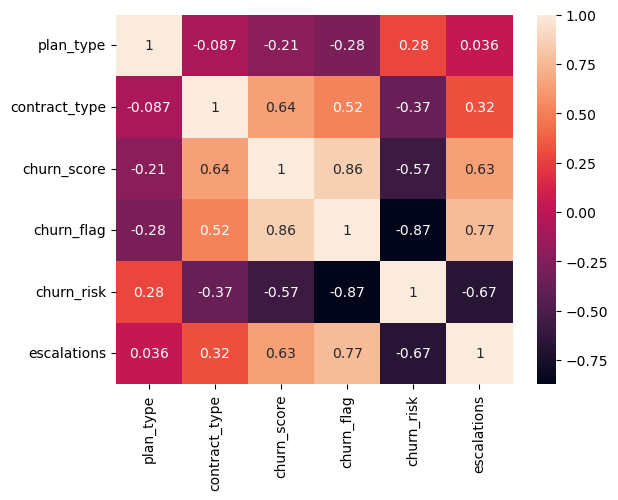

In [84]:
# heatmap using correlation
sns.heatmap(df_encoded.corr(),annot =True)

In [87]:
df_copy['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [97]:
# -----This is not hte correct method to do this because this is providing us the value 
# of the churn risk according to the alphabetical order not on the priority basis.

df_encoded = df_copy[['plan_type','contract_type', 'churn_score',
       'churn_flag', 'churn_risk','escalations']]
order_mapping = {'plan_type' : ['Basic', 'Standard', 'Premium'],
                 'contract_type': ['Monthly','Annual'],
                 'churn_risk': ['low','med','high']}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered= True).codes

C:\Users\avnig\AppData\Local\Temp\ipykernel_13016\3983910570.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered= True).codes
C:\Users\avnig\AppData\Local\Temp\ipykernel_13016\3983910570.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered= True).codes
C:\Users\avnig\AppData\Local\Temp\ipykernel_13016\3983910570.py:11: 

<Axes: >

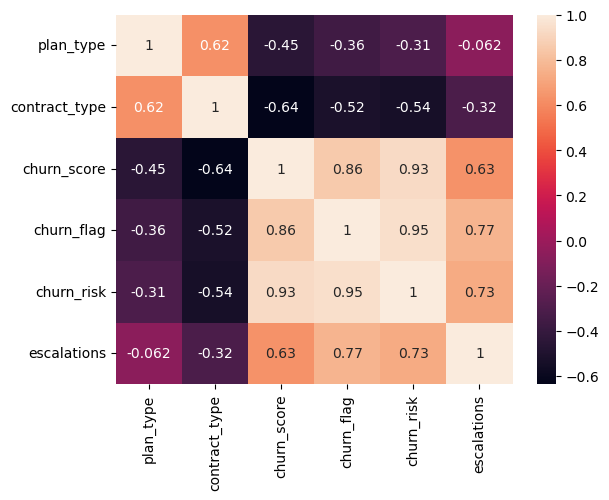

In [100]:
# heatmap using correlation
sns.heatmap(df_encoded.corr(),annot =True)

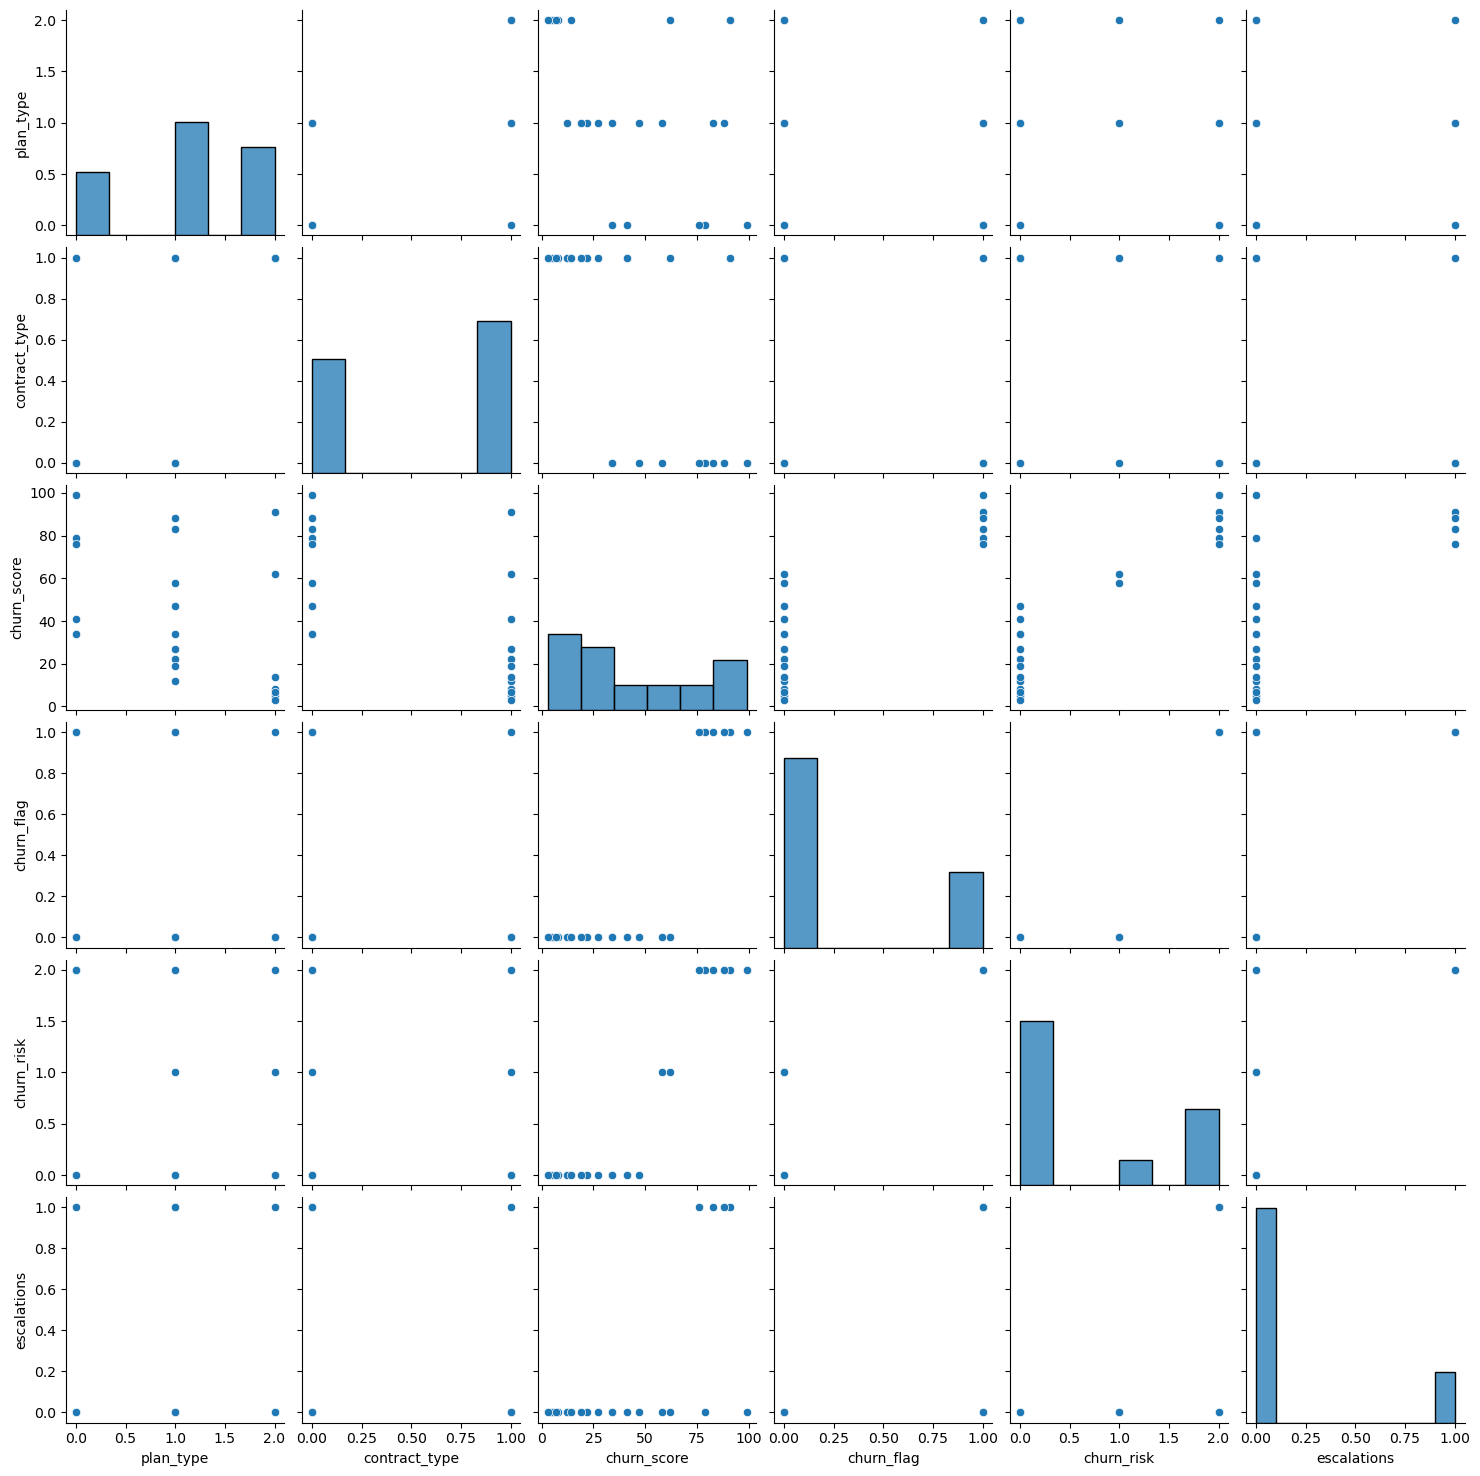

In [101]:
# pair plot - relationship between dataset
sns.pairplot(df_encoded)

In [102]:
df_copy.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

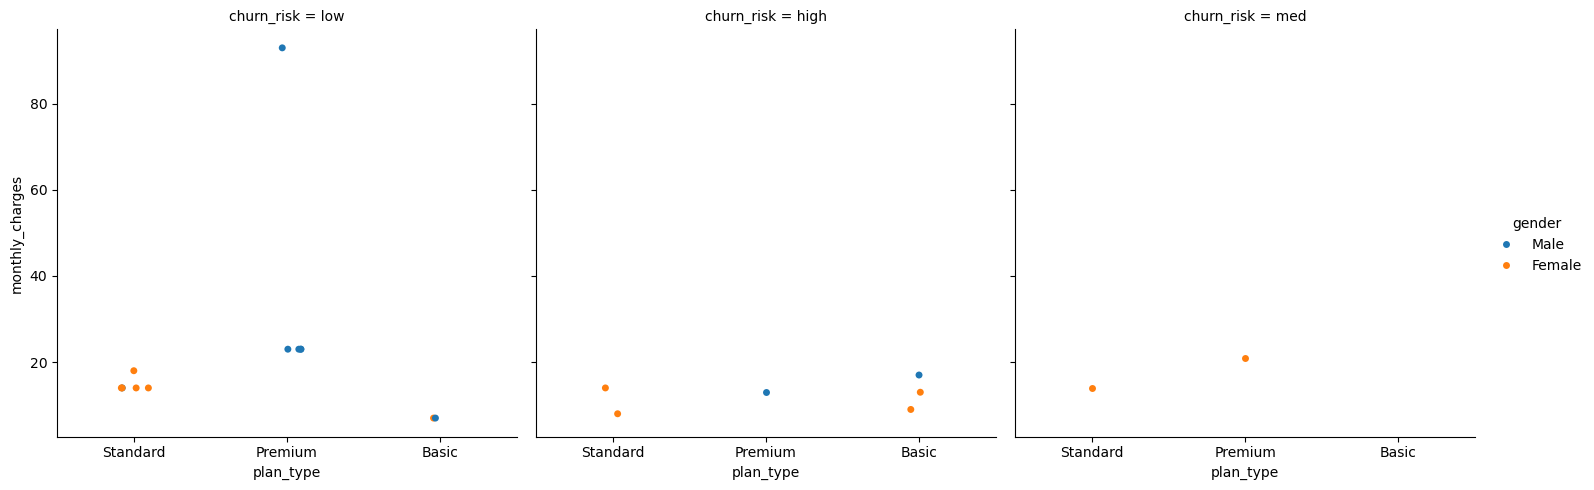

In [103]:
# catplot / Facegrid plot

sns.catplot(
    data = df_copy,
    x = 'plan_type',
    y = 'monthly_charges',
    hue = 'gender',
    col = 'churn_risk'
)

### Pivot table


In [104]:
pd.pivot_table(
    data = df_copy,
    values= 'churn_flag',
    index = 'plan_type',
    aggfunc= 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [107]:
pd.pivot_table(
    data= df_copy,
    index= 'plan_type',
    values= ['monthly_charges','customerid','churn_flag'],
    aggfunc = {
    'customerid' : "nunique",
    'monthly_charges': 'sum',
    'churn_flag': 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
